In [1]:
import numpy as np 
import pandas as pd
df= pd.read_csv('sentiment_ana.csv')

In [2]:
df.head(5)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [3]:
df.columns = ('id','topic','sentiment','tweet')

In [4]:
df.sample(5)

,id,topic,sentiment,tweet
58399,3213,Facebook,Negative,What the fuck is this
2264,2797,Borderlands,Neutral,@ProSyndicate. Dude this sucks my computer run...
42422,10078,PlayerUnknownsBattlegrounds(PUBG),Negative,Even tae oh pubg I won’t ever installing it ha...
13659,8743,NBA2K,Positive,@NBA2K 2k21 already isnt gonna be the greatest...
71471,11042,TomClancysGhostRecon,Positive,some days you appreciate them more than others...


In [5]:
#workflows for this dataset
# 1.remove null values
# 2.kepp only required column
# 3.ckeck class distribution
# 4.text cleaning
# 5.lemmatization
# 6.tf/idf
# 7.encode lables
# 8.train model


In [6]:
df.drop_duplicates(subset = 'tweet', inplace = True)

In [7]:
#1
df.isnull().sum()

id           0
topic        0
sentiment    0
tweet        1
dtype: int64

In [8]:
#why inplace true
df.dropna(inplace = True)

In [9]:
#check
df.isnull().sum()

id           0
topic        0
sentiment    0
tweet        0
dtype: int64

In [10]:
#why two brackets
#2
df = df[['sentiment','tweet']]

In [11]:
df

,sentiment,tweet
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...
...,...,...
74676,Positive,Just realized that the Windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...
74679,Positive,Just realized between the windows partition of...


In [12]:
#3
df['sentiment'].value_counts()

sentiment
Negative      21166
Positive      19065
Neutral       17041
Irrelevant    12216
Name: count, dtype: int64

In [13]:
#4
import re
def clean_text(text):
    text = str(text).lower()
    #remove urls
    text = re.sub(r'http\s+|www\s+',' ',text)
    #remove mentions
    text = re.sub(r'@\w+',' ',text)
    #keep hashtag words but remove hashtags
    text = re.sub(r'#',' ',text)
    #remove numbers
    text = re.sub(r'\d+',' ',text)
    #remove special characters
    text = re.sub(r'[^A-Za-z\s]',' ',text)
    #remove extra spaces
    text = re.sub(r'\s+',' ',text).strip()

    return text

In [14]:
#df = df.copy or a new df should have done before
df['clean'] = df['tweet'].apply(clean_text)

In [15]:
df

,sentiment,tweet,clean
0,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
1,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
4,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
...,...,...,...
74676,Positive,Just realized that the Windows partition of my...,just realized that the windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...,just realized that my mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...,just realized the windows partition of my mac ...
74679,Positive,Just realized between the windows partition of...,just realized between the windows partition of...


In [16]:
#5
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk

In [17]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
corpus = []

In [18]:
for text in df['clean']:
    words = nltk.word_tokenize(text)
    words = [lemmatizer.lemmatize(word)
    for word in words
    if word not in stop_words
    ]
    sentence = " ".join(words)
    corpus.append(sentence)

In [19]:
#6
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 2000, ngram_range = (1,2), min_df = 2, max_df = 0.95)
X = tfidf.fit_transform(corpus).toarray()

In [20]:
#7
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiment'])

In [21]:
#8
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [22]:
X_train,X_test, y_train,  y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [23]:
#logistic regression
lr_model = LogisticRegression(max_iter = 1000, C=2)
lr_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
lr_pred = lr_model.predict(X_test)
print(accuracy_score(y_test,lr_pred))

0.622607569434451


In [25]:
#multinominal naive bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [26]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [27]:
nb_pred = nb_model.predict(X_test)

In [28]:
print(accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

0.5908044322924162
              precision    recall  f1-score   support

           0       0.63      0.25      0.36      2404
           1       0.58      0.79      0.67      4232
           2       0.61      0.49      0.54      3388
           3       0.58      0.68      0.62      3874

    accuracy                           0.59     13898
   macro avg       0.60      0.55      0.55     13898
weighted avg       0.60      0.59      0.57     13898



In [29]:
#linear svm
from sklearn.svm import LinearSVC

In [30]:
sv_model = LinearSVC(C=1.5)
sv_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [31]:
sv_pred = sv_model.predict(X_test)
print(accuracy_score(y_test, sv_pred))

0.6245502950064757


In [32]:
#compare all models
print('lr: ',accuracy_score(y_test,lr_pred))
print('nb: ',accuracy_score(y_test,nb_pred))
print('svm: ',accuracy_score(y_test,sv_pred))

lr:  0.622607569434451
nb:  0.5908044322924162
svm:  0.6245502950064757


In [33]:
#Accuracy is less so converting it into binary classification

In [34]:
df = df[df['sentiment'].isin(['Positive','Negative'])]

In [35]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk

In [36]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
corpus = []

In [37]:
df

,sentiment,tweet,clean
0,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
1,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
4,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
...,...,...,...
74676,Positive,Just realized that the Windows partition of my...,just realized that the windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...,just realized that my mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...,just realized the windows partition of my mac ...
74679,Positive,Just realized between the windows partition of...,just realized between the windows partition of...


In [38]:
for i in df['clean']:
    words = nltk.word_tokenize(i)
    words = [lemmatizer.lemmatize(word)
    for word in words
    if word not in stop_words]
    sentence = ' '.join(words)
    corpus.append(sentence)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 2000, ngram_range = (1,2), min_df = 2, max_df = 0.95)
X1 = tfidf.fit_transform(corpus).toarray()

In [40]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y1 = encoder.fit_transform(df['sentiment'])

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [42]:
X1_train,X1_test, y1_train,  y1_test = train_test_split(X1, y1, test_size = 0.2, random_state = 42)

In [43]:
lr_model1 = LogisticRegression(max_iter = 1000, C=2)
lr_model1.fit(X1_train, y1_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
lr_pred1 = lr_model1.predict(X1_test)
print(accuracy_score(y1_test,lr_pred1))

0.8416801292407108


In [45]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [46]:
nb_model1 = MultinomialNB()
nb_model1.fit(X1_train, y1_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [47]:
nb_pred1 = nb_model1.predict(X1_test)

In [48]:
print(accuracy_score(y1_test, nb_pred1))
print(classification_report(y1_test, nb_pred1))

0.822542562445632
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      4273
           1       0.83      0.78      0.81      3774

    accuracy                           0.82      8047
   macro avg       0.82      0.82      0.82      8047
weighted avg       0.82      0.82      0.82      8047



In [49]:
from sklearn.svm import LinearSVC

In [50]:
sv_model1 = LinearSVC(C=1.5)
sv_model1.fit(X1_train, y1_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [51]:
sv_pred1 = sv_model1.predict(X1_test)
print(accuracy_score(y1_test, sv_pred1))

0.8432956381260097


In [52]:
#compare all models
print('lr: ',accuracy_score(y1_test,lr_pred1))
print('nb: ',accuracy_score(y1_test,nb_pred1))
print('svm: ',accuracy_score(y1_test,sv_pred1))

lr:  0.8416801292407108
nb:  0.822542562445632
svm:  0.8432956381260097


In [53]:
#Built both multiclass and binary Twitter sentiment classifiers using TF-IDF and machine learning models. 
#Observed improved performance in binary classification due to reduced class ambiguity and dataset noise.

In [54]:
#wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [55]:
text = ' '.join(corpus) #this converts all tweets into one big step

In [56]:
wordcloud = WordCloud(width = 400, height = 400, background_color = 'white',collocations = 'False').generate(text)
#collocations = 'False' Otherwise WordCloud sometimes merges words weirdly.

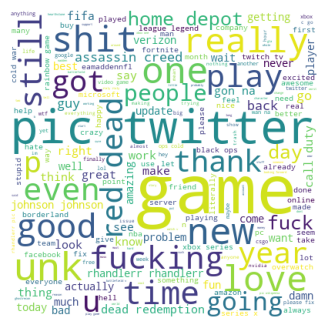

In [57]:
plt.figure(figsize = (4,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()
#words appearing more frequently become larger

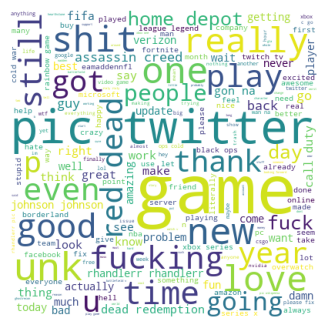

In [58]:
#positive tweet word cloud
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['clean'])
positive_wc = WordCloud(width = 400, height = 400, background_color = 'white', collocations = 'False').generate(positive_text)
plt.figure(figsize = (4,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

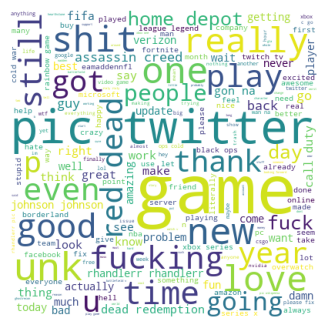

In [59]:
#negative
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['clean'])
negative_wc = WordCloud(width = 400, height = 400, background_color = 'white', collocations = 'False').generate(negative_text)
plt.figure(figsize = (4,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [60]:
df['sentiment'].value_counts()

sentiment
Negative    21166
Positive    19065
Name: count, dtype: int64

In [61]:
print(df[df['sentiment']=='Positive']['clean'].head())

0    i am coming to the borders and i will kill you...
1    im getting on borderlands and i will kill you all
2    im coming on borderlands and i will murder you...
3    im getting on borderlands and i will murder yo...
4    im getting into borderlands and i can murder y...
Name: clean, dtype: object


In [62]:
print(df[df['sentiment']=='Negative']['clean'].head())

23    the biggest dissappoinment in my life came out...
24    the biggest disappointment of my life came a y...
26    the biggest dissappoinment in my life coming o...
27    for the biggest male dissappoinment in my life...
28    the biggest dissappoinment in my life came bac...
Name: clean, dtype: object


In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
cm  = confusion_matrix(y1_test,sv_pred1)

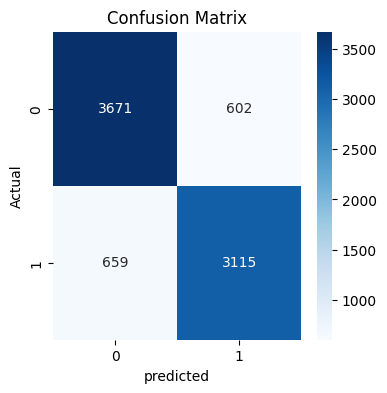

In [65]:
plt.figure(figsize = (4,4))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'g',
    cmap = 'Blues',
)
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [66]:
#accuracy comarison graph
#store accuracy score
lr_acc = accuracy_score(y1_test,lr_pred1)
nb_acc = accuracy_score(y1_test,nb_pred1)
sv_acc = accuracy_score(y1_test,sv_pred1)

In [67]:
#create lists
models = ['Logistic Regression', 'Native Bayes','SVM']
scores = [lr_acc,nb_acc,sv_acc]

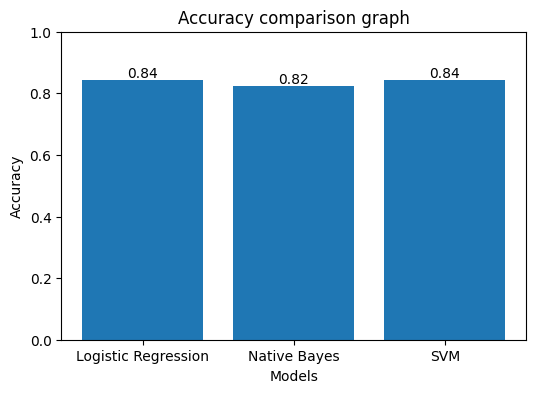

In [68]:
#plot graph
plt.figure(figsize = (6,4))
bar = plt.bar(models,scores)
for bar in bar:
    y_val = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y_val,
        round(y_val,2),
        ha = 'center',
        va = 'bottom'
    )    #this adds text on graph
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy comparison graph')
plt.ylim(0,1)
plt.show()

In [69]:
# Training:
# clean_text()
# → tfidf.fit_transform()
# → model.fit()

# Prediction:
# clean_text()
# → tfidf.transform()
# → model.predict()

In [77]:
#prediction
def predict_sentiment(tweet):
    cleaned = clean_text('tweet')
    vector = tfidf.transform([cleaned]) #[cleaned] because tfidf expects list of documents
    prediction = sv_model1.predict(vector)
    sentiment = encoder.inverse_transform(prediction)  #Earlier LabelEncoder converted labels: neg-0, pos-1 , inverse_transform converts back:1 → Positive
    return sentiment[0] #because output is array, [pos], we extract the value and return it

In [78]:
predict_sentiment("I love this game")

'Negative'

In [79]:
#####  NLP prediction pipeline

# "I LOVE this game!!!"
#         ↓
# clean_text()
#         ↓
# "i love this game"
#         ↓
# tfidf.transform()
#         ↓
# [0.12, 0.88, 0.45, ...]
#         ↓
# svm_model.predict()
#         ↓
# [1]
#         ↓
# encoder.inverse_transform()
#         ↓
# ['Positive']
#         ↓
# return
#         ↓
# Positive

In [80]:
#### save model 
import pickle

In [81]:
pickle.dump(sv_model1, open('sentiment_model.pkl', 'wb')) #save model

In [82]:
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb')) #save tfidf

In [83]:
pickle.dump(encoder, open('encoder.pkl', 'wb'))